In [1]:
# ) Configuração do ambiente e bibliotecas
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu

# Exploratory Data Analysis (EDA) - Dataset de ortopedia
Este notebook contém todo o processo de exploração de dados da base fornecida "ML_Ortopedia_CPAK", para entender a estrutura, distribuições, relações e identificar potenciais padrões para desenvolver um modelo de machine learning.
## 1. Visão geral dos dados e informação básica

In [2]:
# importar dados como dataframe
ortho = pd.read_excel('ML_Ortopedia_CPAK.xlsx')

In [3]:
# verificar estrutura do dataframe
ortho.shape

(265, 22)

In [4]:
#verificar as primeiras linhas do dataframe
ortho.head()

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WAtotal_0,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação
0,67,1,80,158,32.046146,5.0,5,86,4,324,...,54,75,80,1,290,5,1,9,15,8
1,76,2,60,155,24.973985,5.0,5,90,4,357,...,39,60,110,1,480,5,4,3,12,9
2,72,2,93,182,28.076319,1.0,1,45,10,289,...,53,72,100,0,388,0,0,0,0,10
3,67,2,71,163,26.722873,6.0,6,127,2,390,...,16,18,100,0,387,2,0,10,12,9
4,66,1,49,160,19.140625,6.0,6,120,0,285,...,8,8,125,1,284,0,1,2,3,7


In [5]:
# ver os tipos de dados do dataframe e presença de nulls
ortho.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Idade       265 non-null    int64  
 1   Sexo        265 non-null    int64  
 2   Peso        265 non-null    int64  
 3   Altura_cm   265 non-null    int64  
 4   IMC         265 non-null    float64
 5   Grupo_pre   262 non-null    float64
 6   Grupo_pos   265 non-null    int64  
 7   Fle_0       265 non-null    int64  
 8   EVA_0       265 non-null    int64  
 9   PM6_0       265 non-null    int64  
 10  WD_0        265 non-null    int64  
 11  WR_0        265 non-null    int64  
 12  WAtotal_0   265 non-null    int64  
 13  WT_0        265 non-null    int64  
 14  Fle_90      265 non-null    int64  
 15  EVA_90      265 non-null    int64  
 16  PM6_90      265 non-null    int64  
 17  WD_90       265 non-null    int64  
 18  WR_90       265 non-null    int64  
 19  WAtotal_90  265 non-null    i

In [6]:
# mais detalhe sobre nulls
ortho.isnull().sum()

Idade         0
Sexo          0
Peso          0
Altura_cm     0
IMC           0
Grupo_pre     3
Grupo_pos     0
Fle_0         0
EVA_0         0
PM6_0         0
WD_0          0
WR_0          0
WAtotal_0     0
WT_0          0
Fle_90        0
EVA_90        0
PM6_90        0
WD_90         0
WR_90         0
WAtotal_90    0
WT_90         0
Satisfação    0
dtype: int64

In [7]:
# verificar se existem linhas duplicadas
ortho.duplicated().sum()

np.int64(0)

In [8]:
# utilizar .describe() para obter estatísticas descritivas das colunas numéricas
ortho.describe()


,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WAtotal_0,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação
count,265.00000,265.000000,265.000000,265.000000,265.000000,262.000000,265.000000,265.000000,265.000000,265.000000,...,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000,265.000000
mean,71.14717,1.362264,84.215094,168.913208,36.469509,4.595420,4.313208,116.939623,28.056604,264.018868,...,38.509434,48.562264,112.705660,16.581132,316.109434,2.701887,1.286792,10.747170,14.735849,46.215094
std,7.62851,0.481564,81.302856,73.250530,84.215903,1.581883,1.695587,97.147479,148.079756,130.821312,...,60.495249,15.954863,78.643447,121.866086,108.289312,2.455243,1.311666,7.936791,10.226138,189.042210
min,47.00000,1.000000,32.000000,136.000000,14.222222,1.000000,1.000000,10.000000,0.000000,0.000000,...,0.000000,8.000000,70.000000,0.000000,121.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,66.00000,1.000000,66.000000,155.000000,26.122449,4.000000,3.000000,95.000000,4.000000,180.000000,...,26.000000,37.000000,95.000000,0.000000,249.000000,1.000000,0.000000,5.000000,8.000000,8.000000
50%,72.00000,1.000000,76.000000,161.000000,28.731747,5.000000,5.000000,110.000000,6.000000,252.000000,...,34.000000,47.000000,105.000000,1.000000,300.000000,2.000000,1.000000,9.000000,13.000000,10.000000
75%,76.00000,2.000000,86.000000,170.000000,32.000000,6.000000,5.000000,120.000000,8.000000,330.000000,...,44.000000,59.000000,116.000000,3.000000,360.000000,4.000000,2.000000,15.000000,20.000000,10.000000
max,89.00000,2.000000,999.000000,999.000000,999.000000,9.000000,9.000000,999.000000,999.000000,999.000000,...,999.000000,96.000000,999.000000,999.000000,999.000000,11.000000,8.000000,40.000000,55.000000,999.000000


## 2. Transformação dos dados

Transformação da base de dados original para facilitar a análise.

In [9]:
'''
Verificou-se a existencia de '999' em algumas colunas, o que pode indicar dados mal preenchidos. 
Para lidar com isso, vamos substituir os valores '999' por NaN, que é a representação de valores ausentes no pandas.
Justificação: 999 é uma flag de valor em falta em TODA a base — não é um valor clínico legítimo em nenhuma das variáveis 
(idades, pesos, alturas, scores, distâncias, etc.), pelo que a substituição global por NaN é segura.
'''


# nova dataframe com '999' substituído por NaN para deixar a original sem alterações
ortho1 = ortho.copy()
ortho1.replace(999, np.nan, inplace=True)

In [10]:
ortho1.isnull().sum()

Idade          0
Sexo           0
Peso           2
Altura_cm      2
IMC            2
Grupo_pre      3
Grupo_pos      0
Fle_0          3
EVA_0          6
PM6_0          3
WD_0           0
WR_0           0
WAtotal_0      1
WT_0           0
Fle_90         2
EVA_90         4
PM6_90         2
WD_90          0
WR_90          0
WAtotal_90     0
WT_90          0
Satisfação    10
dtype: int64

In [11]:
#visualizar os casos que possuem valores nulos, listando por linha 
missing_values = ortho1[ortho1.isnull().any(axis=1)]
missing_values

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WAtotal_0,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação
24,60,2,74.0,166.0,26.854406,4.0,4,128.0,7.0,199.0,...,31.0,46,100.0,0.0,480.0,1,1,6,8,NaN
31,70,1,63.0,164.0,23.423557,6.0,6,78.0,7.0,116.0,...,43.0,59,120.0,0.0,300.0,2,0,8,10,NaN
40,76,1,75.0,165.0,27.548209,5.0,5,100.0,7.0,390.0,...,32.0,43,112.0,2.0,300.0,3,1,13,17,NaN
43,83,2,78.0,171.0,26.674874,5.0,5,130.0,5.0,255.0,...,19.0,24,92.0,1.0,255.0,3,0,21,24,NaN
53,73,1,NaN,NaN,NaN,5.0,5,98.0,6.0,109.0,...,38.0,53,111.0,1.0,232.0,0,0,8,8,8.0
61,79,1,60.0,155.0,24.973985,5.0,5,120.0,5.0,64.0,...,18.0,28,NaN,NaN,192.0,7,0,8,15,10.0
65,70,1,94.0,150.0,41.777778,6.0,6,NaN,NaN,94.0,...,57.0,77,98.0,0.0,204.0,2,0,19,21,10.0
66,77,2,83.0,175.0,27.102041,6.0,6,NaN,6.0,178.0,...,33.0,47,93.0,0.0,291.0,0,0,5,5,9.0
75,65,2,NaN,NaN,NaN,2.0,2,130.0,7.0,288.0,...,27.0,45,110.0,2.0,277.0,0,1,5,6,10.0
77,67,1,62.0,157.0,25.153150,5.0,5,NaN,5.0,276.0,...,26.0,38,90.0,1.0,298.0,1,2,8,11,8.0


In [12]:
# eliminar os casos com valores nulos, pois são poucos e não devem impactar a análise
ortho1 = ortho1.dropna(subset = ['Grupo_pre'])
          

In [13]:
# verificar novamente a presença de valores nulos
ortho1.isnull().sum()

Idade          0
Sexo           0
Peso           2
Altura_cm      2
IMC            2
Grupo_pre      0
Grupo_pos      0
Fle_0          3
EVA_0          6
PM6_0          3
WD_0           0
WR_0           0
WAtotal_0      1
WT_0           0
Fle_90         2
EVA_90         4
PM6_90         2
WD_90          0
WR_90          0
WAtotal_90     0
WT_90          0
Satisfação    10
dtype: int64

In [14]:
# conversão do tipo de "grupo_pre" para int64
ortho1['Grupo_pre'] = ortho1['Grupo_pre'].astype('int64')

In [15]:
'''
Substituição da codificação da variável 'Sexo' por outros valores numéricos para 
não induzir o modelo em erro hierárquico, onde o valor 2 (masculino) 
seria considerado maior que o valor 1 (feminino), o que não é o caso.
original 1: feminino, 2: masculino
nova codificação 0: feminino, 1: masculino
'''

ortho1.replace({'Sexo': {1: 0, 2: 1}}, inplace = True)

In [16]:
# alteração do tipo de dados das variáveis "Grupo_pre" e "Sexo" para category
ortho1["Grupo_pre"] = ortho1["Grupo_pre"].astype("category")
ortho1["Sexo"] = ortho1["Sexo"].astype("category")
ortho1["Grupo_pos"] = ortho1["Grupo_pos"].astype("category")

In [17]:
# gerar a variável de interesse "mudanca_CPAK", que indica se houve mudança no grupo de classificação entre o pré e o pós-operatório.
ortho1['mudanca_CPAK'] = (ortho1['Grupo_pre'] != ortho1['Grupo_pos']).astype("category")

In [18]:
# verificar o número de linhas e de colunas após a limpeza dos dados
ortho1.shape

(262, 23)

In [19]:
# verificar os tipos de variaveis 
ortho1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262 entries, 0 to 264
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Idade         262 non-null    int64   
 1   Sexo          262 non-null    category
 2   Peso          260 non-null    float64 
 3   Altura_cm     260 non-null    float64 
 4   IMC           260 non-null    float64 
 5   Grupo_pre     262 non-null    category
 6   Grupo_pos     262 non-null    category
 7   Fle_0         259 non-null    float64 
 8   EVA_0         256 non-null    float64 
 9   PM6_0         259 non-null    float64 
 10  WD_0          262 non-null    int64   
 11  WR_0          262 non-null    int64   
 12  WAtotal_0     261 non-null    float64 
 13  WT_0          262 non-null    int64   
 14  Fle_90        260 non-null    float64 
 15  EVA_90        258 non-null    float64 
 16  PM6_90        260 non-null    float64 
 17  WD_90         262 non-null    int64   
 18  WR_90         2

In [20]:
# avaliar consistencia dos dados, verificando se existem valores fora do esperado para cada variavel
ortho1.describe()

,Idade,Peso,Altura_cm,IMC,Fle_0,EVA_0,PM6_0,WD_0,WR_0,WAtotal_0,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação
count,262.000000,260.000000,260.000000,260.000000,259.000000,256.000000,259.000000,262.000000,262.000000,261.000000,262.000000,260.000000,258.000000,260.000000,262.000000,262.000000,262.000000,262.000000,252.00000
mean,71.133588,77.342308,162.653846,29.161914,106.640927,5.558594,255.243243,10.744275,3.068702,34.858238,48.538168,105.850000,1.538760,310.350000,2.729008,1.270992,10.740458,14.740458,8.84127
std,7.658498,15.021803,10.371264,4.534809,22.281463,2.387156,104.514560,3.476173,2.745085,12.381089,16.005880,13.812192,1.968737,90.727075,2.455551,1.286177,7.969855,10.269613,1.49854
min,47.000000,32.000000,136.000000,14.222222,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,70.000000,0.000000,121.000000,0.000000,0.000000,0.000000,0.000000,1.00000
25%,66.000000,66.000000,155.000000,26.115156,95.000000,4.000000,180.000000,9.000000,2.000000,26.000000,37.250000,95.000000,0.000000,249.000000,1.000000,0.000000,5.000000,8.000000,8.00000
50%,72.000000,76.000000,161.500000,28.715101,110.000000,6.000000,249.000000,10.000000,3.000000,34.000000,47.000000,104.000000,1.000000,300.000000,2.000000,1.000000,9.000000,13.000000,9.00000
75%,76.000000,86.000000,170.000000,31.896222,120.000000,7.250000,327.000000,13.000000,4.000000,43.000000,59.000000,116.000000,2.750000,360.000000,4.000000,2.000000,15.000000,20.000000,10.00000
max,89.000000,137.000000,198.000000,42.324275,150.000000,10.000000,522.000000,20.000000,31.000000,68.000000,96.000000,153.000000,8.000000,600.000000,11.000000,8.000000,40.000000,55.000000,10.00000


In [21]:
# report profile do dataframe ortho 
# from pandas_profiling import ProfileReport
# profile = ProfileReport(ortho, title="Pandas Profiling Report", explorative=True)
# profile.to_file("pandas_profiling_report_.html")

In [22]:
# WR_0 tem uma escala de 0 a 8, transformar valores de variavel WR_0>8 em nan
ortho1.loc[ortho1['WR_0'] > 8, 'WR_0'] = np.nan

In [23]:
# for loop para imputação de  missings com mediana de cada coluna numérica
cols_missing = ['Fle_0', 'EVA_0', 'PM6_0', 'WR_0', 'Peso', 'Altura_cm']
for col in cols_missing:
    ortho1[col].fillna(ortho1[col].median(), inplace=True)

C:\Users\edu23\AppData\Local\Temp\ipykernel_26192\2126869914.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ortho1[col].fillna(ortho1[col].median(), inplace=True)


In [24]:
# confirmar o estado de valores nulos após imputação inicial
ortho1.isnull().sum()

Idade            0
Sexo             0
Peso             0
Altura_cm        0
IMC              2
Grupo_pre        0
Grupo_pos        0
Fle_0            0
EVA_0            0
PM6_0            0
WD_0             0
WR_0             0
WAtotal_0        1
WT_0             0
Fle_90           2
EVA_90           4
PM6_90           2
WD_90            0
WR_90            0
WAtotal_90       0
WT_90            0
Satisfação      10
mudanca_CPAK     0
dtype: int64

In [25]:
# verificar os casos que ainda possuem valores nulos, listando por linha
# IMC não foi imputado, pois é uma variável derivada de peso e altura, e a imputaçao de peso e altura já foi realizada.
cols = ['IMC', 'WAtotal_0']
missing_values = ortho1[ortho1[cols].isnull().any(axis=1)]
missing_values

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Grupo_pos,Fle_0,EVA_0,PM6_0,...,WT_0,Fle_90,EVA_90,PM6_90,WD_90,WR_90,WAtotal_90,WT_90,Satisfação,mudanca_CPAK
53,73,0,76.0,161.5,NaN,5,5,98.0,6.0,109.0,...,53,111.0,1.0,232.0,0,0,8,8,8.0,False
75,65,1,76.0,161.5,NaN,2,2,130.0,7.0,288.0,...,45,110.0,2.0,277.0,0,1,5,6,10.0,False
202,72,0,72.0,155.0,29.968783,4,4,100.0,5.0,10.0,...,33,90.0,5.0,250.0,6,4,23,33,6.0,False


In [26]:
# calculo dos valores nulos da variavel IMC partir do peso e altura, 
# utilizando a fórmula: IMC = Peso / (Altura_cm/100)^2

#criação de alias para nulos de IMC que possuem peso e altura válidos
IMC_nulls = ortho1['IMC'].isna() & ortho1['Peso'].notna() & ortho1['Altura_cm'].notna() & (ortho1['Altura_cm'] > 0)

# cálculo do IMC para os casos com valores nulos, 
# fórmula: IMC = Peso / (Altura_cm)^2

ortho1.loc[IMC_nulls, 'IMC'] = ortho1.loc[IMC_nulls, 'Peso'] / ((ortho1.loc[IMC_nulls, 'Altura_cm']/100) ** 2)


In [27]:
# WAtotal_0 não foi imputado pois é possivel calcular através dos valores válidos de WT, WR e WD
# corrigir o missing value de WAtotal com calculo WATotal = WT - (WR + WD)
missing_WA0 = ortho1[ortho1['WAtotal_0'].isnull()] 
ortho1.loc[missing_WA0.index, 'WAtotal_0'] = ortho1.loc[missing_WA0.index, 'WT_0']- (ortho1.loc[missing_WA0.index, 'WR_0'] + ortho1.loc[missing_WA0.index, 'WD_0'])


In [28]:
# verificar final de valores nulos
ortho1.isnull().sum()   
 

Idade            0
Sexo             0
Peso             0
Altura_cm        0
IMC              0
Grupo_pre        0
Grupo_pos        0
Fle_0            0
EVA_0            0
PM6_0            0
WD_0             0
WR_0             0
WAtotal_0        0
WT_0             0
Fle_90           2
EVA_90           4
PM6_90           2
WD_90            0
WR_90            0
WAtotal_90       0
WT_90            0
Satisfação      10
mudanca_CPAK     0
dtype: int64

In [29]:
ortho1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262 entries, 0 to 264
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Idade         262 non-null    int64   
 1   Sexo          262 non-null    category
 2   Peso          262 non-null    float64 
 3   Altura_cm     262 non-null    float64 
 4   IMC           262 non-null    float64 
 5   Grupo_pre     262 non-null    category
 6   Grupo_pos     262 non-null    category
 7   Fle_0         262 non-null    float64 
 8   EVA_0         262 non-null    float64 
 9   PM6_0         262 non-null    float64 
 10  WD_0          262 non-null    int64   
 11  WR_0          262 non-null    float64 
 12  WAtotal_0     262 non-null    float64 
 13  WT_0          262 non-null    int64   
 14  Fle_90        260 non-null    float64 
 15  EVA_90        258 non-null    float64 
 16  PM6_90        260 non-null    float64 
 17  WD_90         262 non-null    int64   
 18  WR_90         2

In [30]:
# após limpeza dos dados, o dataset possui 0 valores nulos nas variaveis de interesse para o modelo
# retira-se tambem os dados que não interessam para o modelo, como as variáveis de classificação pós-operatória, para facilitar analise exploratória
# definição de listas de variáveis numéricas e categóricas usadas na EDA

ortho2 = ortho1.copy()

# definir lista com variaveis categóricas
vars_categoricas = ortho1.select_dtypes(include=['category']).columns.tolist()
#for loop para definir as variáveis numéricas, que são as que ainda tem missing values.
vars_numericas = ortho1.select_dtypes(include=['int64', 'float64']).columns.tolist()

# limpeza final de dados, eliminando os casos que ainda possuem valores nulos
for col in vars_numericas:
    ortho2[col].fillna(ortho2[col].median(), inplace=True)

C:\Users\edu23\AppData\Local\Temp\ipykernel_26192\2763945512.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ortho2[col].fillna(ortho2[col].median(), inplace=True)


In [31]:
ortho2.isnull().sum()


Idade           0
Sexo            0
Peso            0
Altura_cm       0
IMC             0
Grupo_pre       0
Grupo_pos       0
Fle_0           0
EVA_0           0
PM6_0           0
WD_0            0
WR_0            0
WAtotal_0       0
WT_0            0
Fle_90          0
EVA_90          0
PM6_90          0
WD_90           0
WR_90           0
WAtotal_90      0
WT_90           0
Satisfação      0
mudanca_CPAK    0
dtype: int64

## 3. EDA

Depois da limpeza dos dados, inicia-se a exploração estatística e visual.

In [32]:
# cópia da dataframe para realizar a EDA, mantendo a original sem alterações
ortho_eda = ortho2.copy()
# separação do dataset removendo variáveis que causam data leakage
# (variáveis com informação pós-operatória)

ortho_eda = ortho2.drop(columns = [
    'Fle_90','EVA_90','PM6_90','WD_90','WR_90','WAtotal_90',
    'WT_90', 'Satisfação'
    ]
    )

# definição de variaveis categóricas e numéricas para a EDA, considerando a nova dataframe sem variáveis de data leakage
vars_categoricas_eda =  ortho_eda.select_dtypes(include=['category']).columns.tolist()
vars_numericas_eda = ortho_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()

Gráficos simples para visualização de variaveis categóricas e numéricas

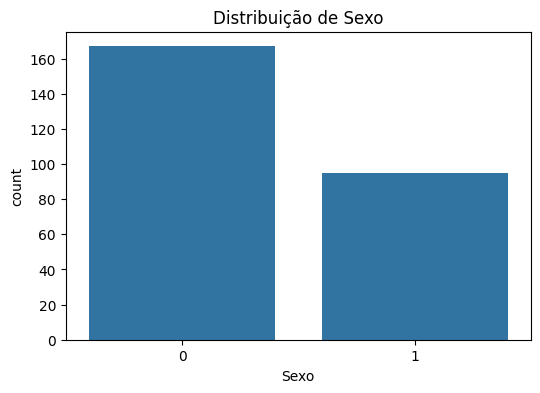

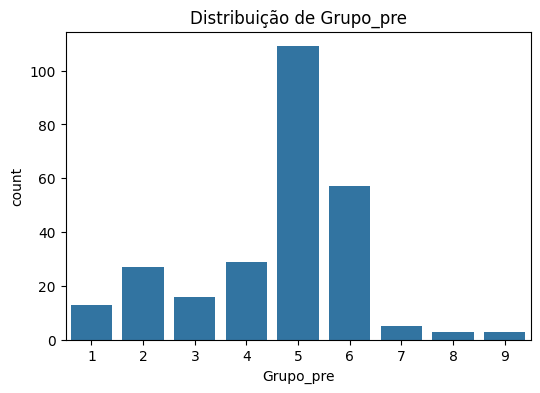

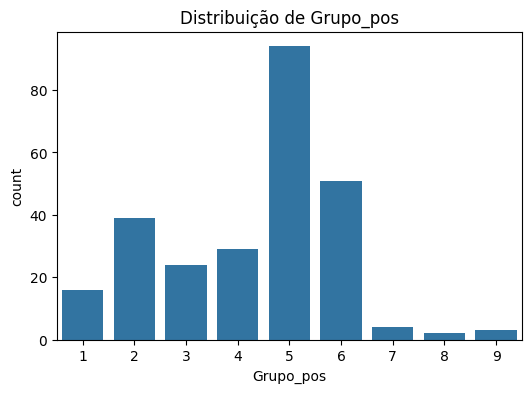

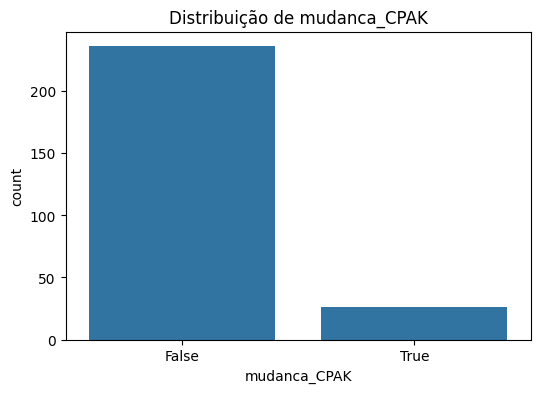

In [33]:
# para categóricas: countplot
for col in vars_categoricas_eda:
    plt.figure(figsize=(6,4))
    sns.countplot(data=ortho1, x=col)
    plt.title(f'Distribuição de {col}')
    plt.show()

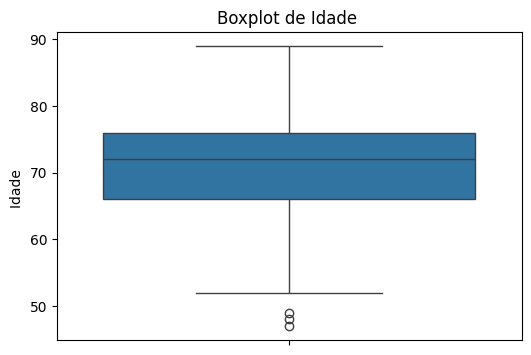

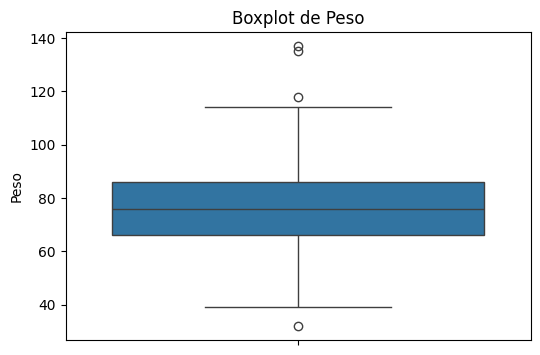

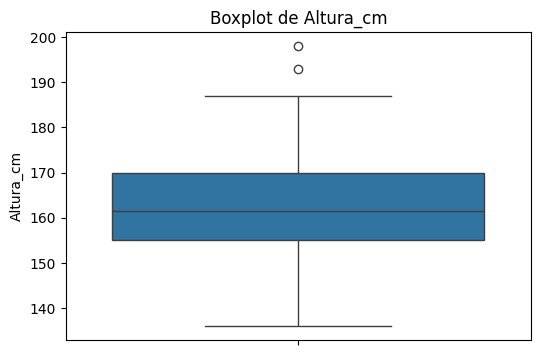

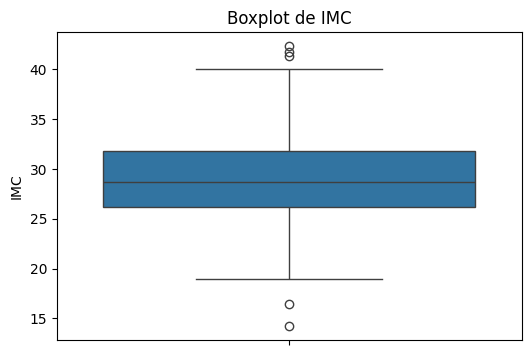

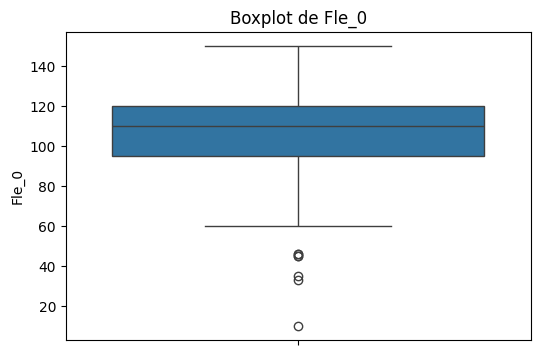

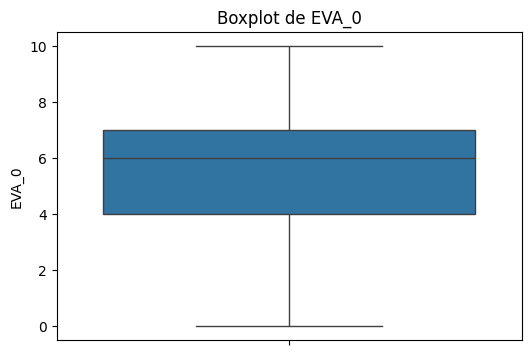

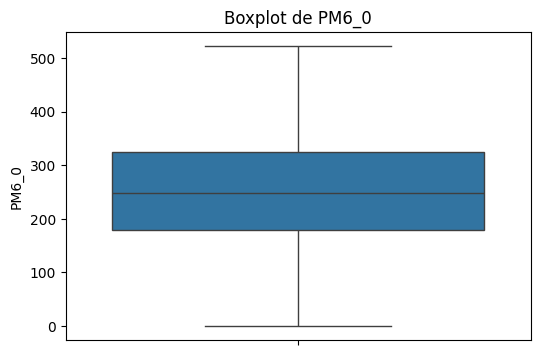

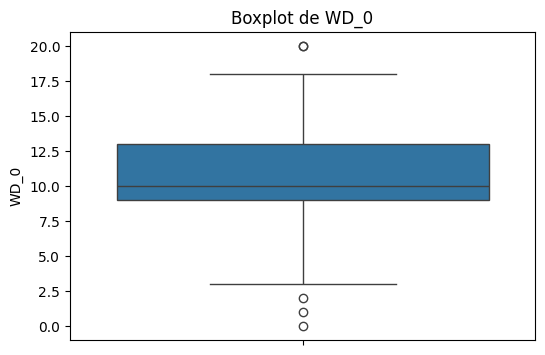

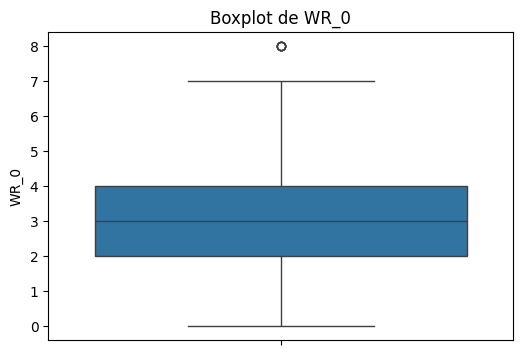

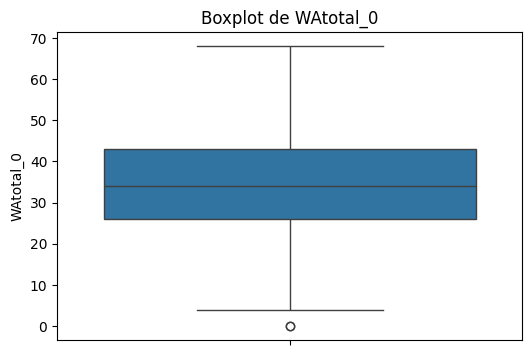

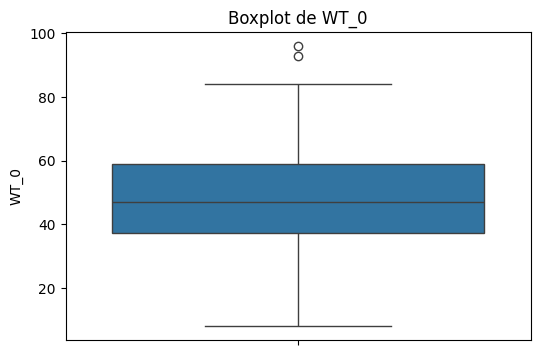

In [34]:
# para numéricas: boxplot
for col in vars_numericas_eda:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=ortho1, y=col)
    plt.title(f'Boxplot de {col}')
    plt.show()

Apesar da presença de alguns outliers, decidimos continuar sem imputar utilizando os IQRs devido ao tamanho diminuto do Dataset.
Esta decisão tambem se prende pela possivel interpretação clinica destes outliers.

### 3.2 Analise Bivariada Comparação estatística das variáveis numéricas por classe (mudanca_CPAK)

Para cada variável numérica, compara-se a **mediana** e o **IQR** entre as classes 0 (sem mudança) e 1 (com mudança), e aplica-se o **teste de Mann-Whitney U** para verificar se as diferenças observadas nos boxplots são estatisticamente significativas.

In [36]:
# verificar a quantidade de casos em cada categoria da variável de interesse "mudanca_CPAK"
# em valores absolutos e relativos
tabela_mudanca_CPAK = (
    pd.concat(
        [
            ortho_eda["mudanca_CPAK"].value_counts(dropna=False),
            ortho_eda["mudanca_CPAK"].value_counts(normalize=True, dropna=False).mul(100).round(2)
        ],
        axis=1
        )
)

tabela_mudanca_CPAK.columns = ["Frequencia_Absoluta", "Frequencia_Relativa_%"]
tabela_mudanca_CPAK

,Frequencia_Absoluta,Frequencia_Relativa_%
mudanca_CPAK,,
False,236,90.08
True,26,9.92


In [37]:
# cálculo de estatísticas descritivas por classe e teste de Mann-Whitney U
results = []
for var in vars_numericas_eda:
    for classe in [False, True]:
        grupo = ortho_eda[ortho_eda['mudanca_CPAK'] == classe][var].dropna()
        q1 = grupo.quantile(0.25)
        q3 = grupo.quantile(0.75)
        results.append({
            'Variável': var,
            'Classe': classe,
            'Mediana': round(grupo.median(), 2),
            'IQR': round(q3 - q1, 2),
            'Q1': round(q1, 2),
            'Q3': round(q3, 2),
            'N': len(grupo)
        })

df_stats = pd.DataFrame(results)
df_stats_pivot = df_stats.pivot(index='Variável', columns='Classe', values=['N', 'Mediana', 'IQR', 'Q1', 'Q3'])
df_stats_pivot.columns = [f'{stat}_classe{cls}' for stat, cls in df_stats_pivot.columns]

# Teste Mann-Whitney U
mw_results = []
for var in vars_numericas_eda:
    g0 = ortho2[ortho2['mudanca_CPAK'] == False][var].dropna()
    g1 = ortho2[ortho2['mudanca_CPAK'] == True][var].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
    mw_results.append({'Variável': var, 'U_statistic': round(stat, 2), 'p_value': round(p, 4), 'Significativo (p<0.05)': p < 0.05})

df_mw = pd.DataFrame(mw_results).set_index('Variável')
df_final = df_stats_pivot.join(df_mw)
df_final

,N_classeFalse,N_classeTrue,Mediana_classeFalse,Mediana_classeTrue,IQR_classeFalse,IQR_classeTrue,Q1_classeFalse,Q1_classeTrue,Q3_classeFalse,Q3_classeTrue,U_statistic,p_value,Significativo (p<0.05)
Variável,,,,,,,,,,,,,
Altura_cm,236.0,26.0,160.5,166.50,15.00,13.75,155.00,161.25,170.00,175.00,2323.5,0.0423,True
EVA_0,236.0,26.0,6.0,5.50,3.00,3.50,4.00,3.50,7.00,7.00,3153.0,0.8161,False
Fle_0,236.0,26.0,110.0,120.00,28.00,26.75,92.00,106.25,120.00,133.00,1908.0,0.0015,True
IMC,236.0,26.0,28.9,25.56,5.33,7.02,26.67,23.87,32.01,30.89,3998.5,0.0112,True
Idade,236.0,26.0,72.0,65.50,10.00,13.00,67.00,60.00,77.00,73.00,4014.5,0.0098,True
PM6_0,236.0,26.0,242.5,350.50,132.25,151.50,177.75,267.00,310.00,418.50,1437.5,0.0000,True
Peso,236.0,26.0,76.5,71.50,20.25,17.00,66.75,64.75,87.00,81.75,3478.0,0.2639,False
WAtotal_0,236.0,26.0,34.0,30.50,18.00,17.50,26.00,24.25,44.00,41.75,3517.5,0.2206,False
WD_0,236.0,26.0,10.0,10.00,5.00,2.75,8.00,9.00,13.00,11.75,3251.0,0.6172,False


C:\Users\edu23\AppData\Local\Temp\ipykernel_26192\2485189262.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ortho_eda, x='mudanca_CPAK', y=var, palette= {'False': 'lightcoral', 'True': 'limegreen'}, ax=ax)
C:\Users\edu23\AppData\Local\Temp\ipykernel_26192\2485189262.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ortho_eda, x='mudanca_CPAK', y=var, palette= {'False': 'lightcoral', 'True': 'limegreen'}, ax=ax)
C:\Users\edu23\AppData\Local\Temp\ipykernel_26192\2485189262.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(da

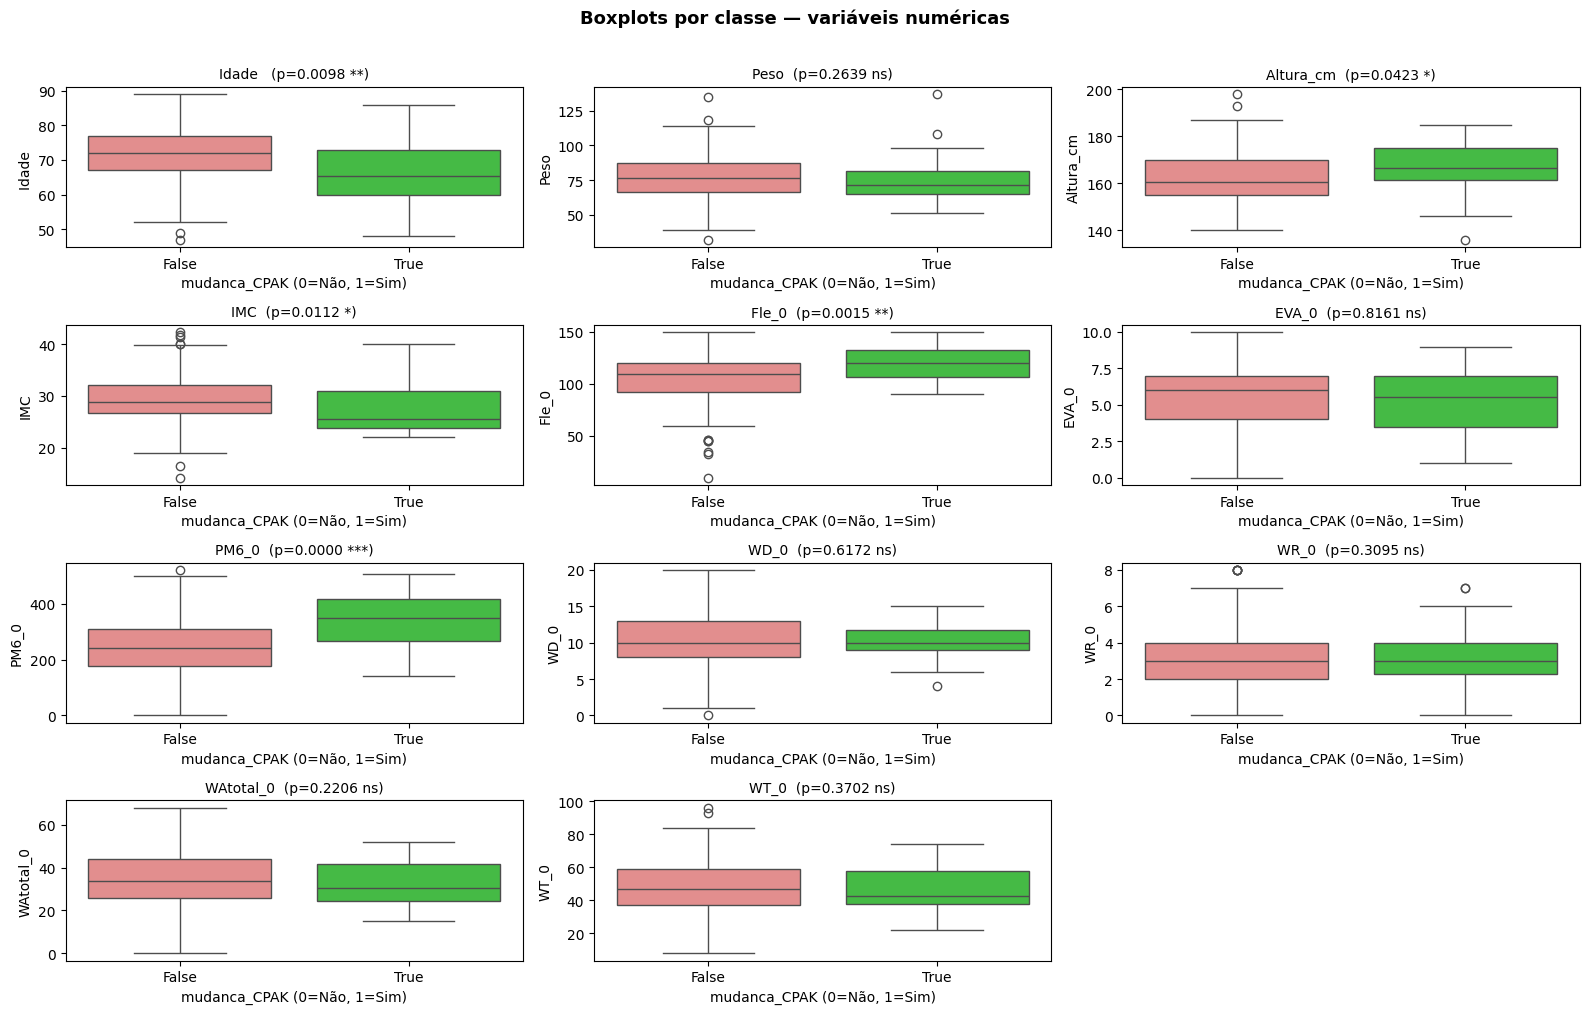

In [38]:
# Boxplots com anotação da mediana por classe
fig, axes = plt.subplots(4, 3, figsize=(16, 10))
axes = axes.flatten()

#criação de boxplots para cada variável numérica, com anotação da mediana e p-value do teste Mann-Whitney U
for i, var in enumerate(vars_numericas_eda):
    ax = axes[i]
    sns.boxplot(data=ortho_eda, x='mudanca_CPAK', y=var, palette= {'False': 'lightcoral', 'True': 'limegreen'}, ax=ax)
    
    for classe, x_pos in zip([0, 1], [0, 1]):
        med = ortho_eda[ortho_eda['mudanca_CPAK'] == classe][var].median()
        ax.text(x_pos, med, f'  Med={med:.1f}', va='center', fontsize=8, color='black', fontweight='bold')
    
    # adicionar p-value no título
    p = df_mw.loc[var, 'p_value']
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_title(f'{var}  (p={p:.4f} {sig})', fontsize=10)
    ax.set_xlabel('mudanca_CPAK (0=Não, 1=Sim)')

#remover os eixos que sobram (há mais subplots do que variáveis numéricas)
for j in range(len(vars_numericas_eda), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots por classe — variáveis numéricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close()

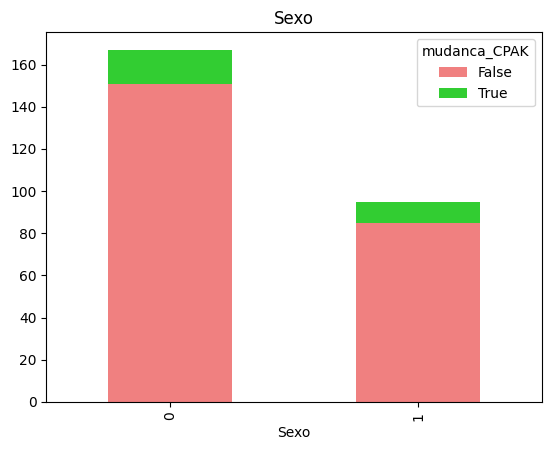

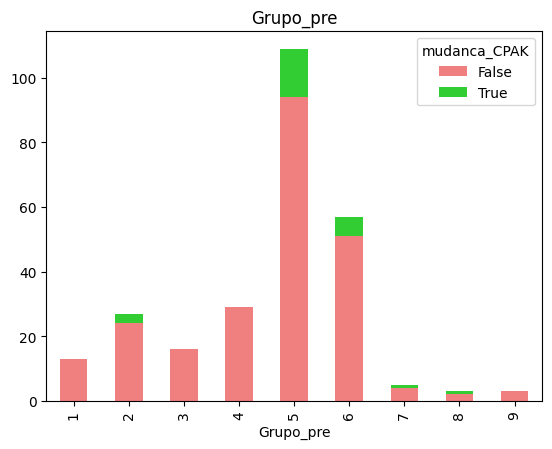

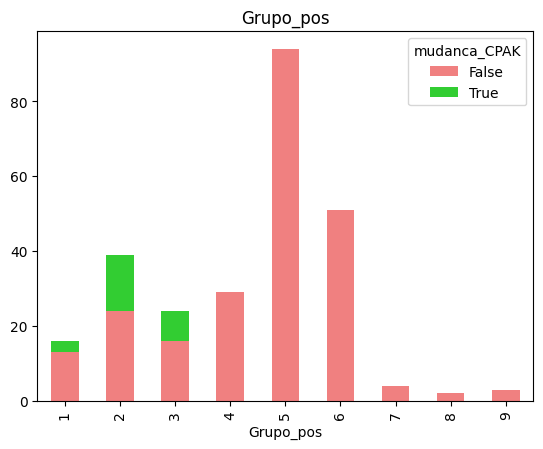

In [39]:
# gráficos de barras das variáveis categóricas face à variável de interesse "mudanca_CPAK"
for var in [v for v in vars_categoricas_eda if v != 'mudanca_CPAK']:
    pd.crosstab(ortho_eda[var], ortho_eda['mudanca_CPAK']).plot(
        kind='bar', stacked=True,
        color=['lightcoral', 'limegreen']
    )
    plt.title(var)
    plt.show()
    plt.close()

### 3.2 Análise de correlações e redundância

In [ ]:
# separação do dataset removendo o resto das variáveis que causam data leakage

ortho_eda_clean = ortho_eda.drop(columns = ['Grupo_pos'])

In [ ]:
# análise de correlação entre variáveis numéricas e target

ortho_eda_clean.corr(method = 'spearman')

,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Fle_0,EVA_0,PM6_0,WD_0,WR_0,WAtotal_0,WT_0,mudanca_CPAK
Idade,1.000000,-0.017705,-0.178138,-0.161306,-0.112986,-0.103372,-0.101746,0.060025,-0.279752,-0.067015,-0.086941,0.067036,0.025671,-0.159920
Sexo,-0.017705,1.000000,0.416248,0.675705,-0.020890,-0.142504,0.203692,-0.161417,0.307819,-0.148563,-0.149042,-0.166499,-0.175139,0.015203
Peso,-0.178138,0.416248,1.000000,0.551418,0.744453,-0.131264,0.023741,-0.065397,0.201471,0.012324,-0.027387,0.011330,0.008525,-0.069236
Altura_cm,-0.161306,0.675705,0.551418,1.000000,-0.097181,-0.061920,0.115136,-0.147971,0.400042,-0.083547,-0.019112,-0.143969,-0.126049,0.125792
IMC,-0.112986,-0.020890,0.744453,-0.097181,1.000000,-0.120575,-0.065533,0.052824,-0.074057,0.081481,0.003587,0.124164,0.112037,-0.157062
Grupo_pre,-0.103372,-0.142504,-0.131264,-0.061920,-0.120575,1.000000,0.042595,0.008382,0.037226,-0.016993,-0.027459,0.063488,0.050702,0.107998
Fle_0,-0.101746,0.203692,0.023741,0.115136,-0.065533,0.042595,1.000000,-0.269893,0.325783,-0.242705,-0.261073,-0.320932,-0.337659,0.196197
EVA_0,0.060025,-0.161417,-0.065397,-0.147971,0.052824,0.008382,-0.269893,1.000000,-0.360230,0.500606,0.207957,0.497193,0.524326,-0.014481
PM6_0,-0.279752,0.307819,0.201471,0.400042,-0.074057,0.037226,0.325783,-0.360230,1.000000,-0.289503,-0.111640,-0.367093,-0.359095,0.275251
WD_0,-0.067015,-0.148563,0.012324,-0.083547,0.081481,-0.016993,-0.242705,0.500606,-0.289503,1.000000,0.309120,0.687236,0.775629,-0.031026


<Axes: >

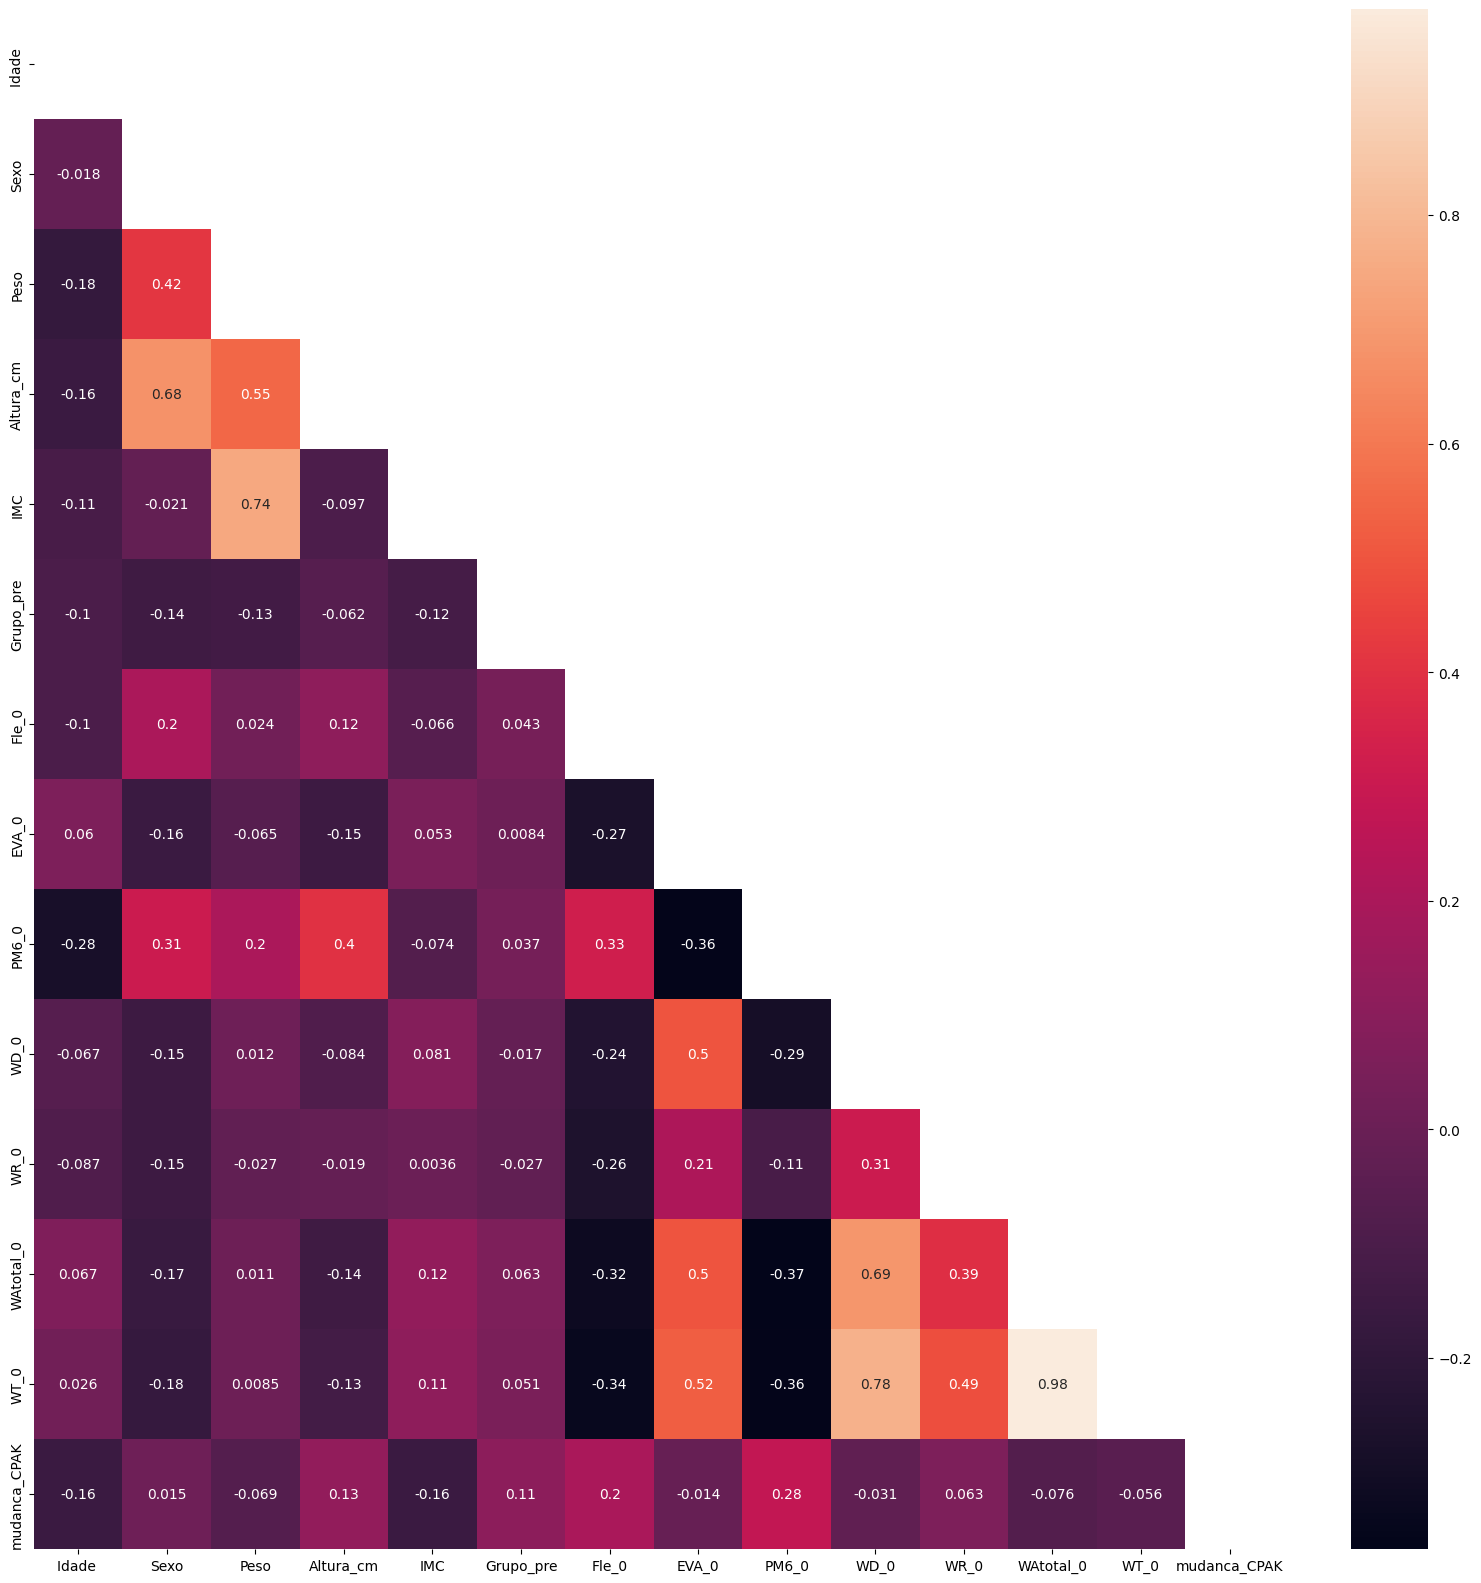

In [42]:
# Criação de matriz de correlações para visualização

matrix = np.triu(ortho_eda_clean.corr(method='spearman'))

plt.figure(figsize=(20,20))
sns.heatmap(ortho_eda_clean.corr(method='spearman'), annot=True, mask=matrix)

<Axes: >

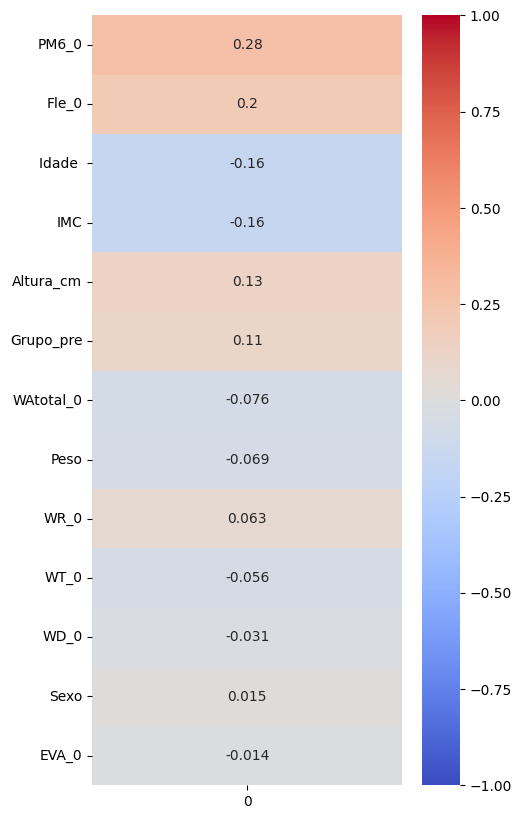

In [43]:
# gráfico das correlações com a target (variável dependente)
correlations = ortho_eda_clean.corrwith(ortho_eda_clean['mudanca_CPAK'], method='spearman').iloc[:-1].to_frame()
correlations['abs'] = correlations[0].abs()
sorted_correlations = correlations.sort_values('abs', ascending=False)[0]

fig,ax = plt.subplots(figsize=(5,10))
sns.heatmap(sorted_correlations.to_frame(), cmap='coolwarm', annot=True, vmin=-1, vmax=1, ax=ax)

C:\Users\edu23\AppData\Local\Temp\ipykernel_26192\114253651.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


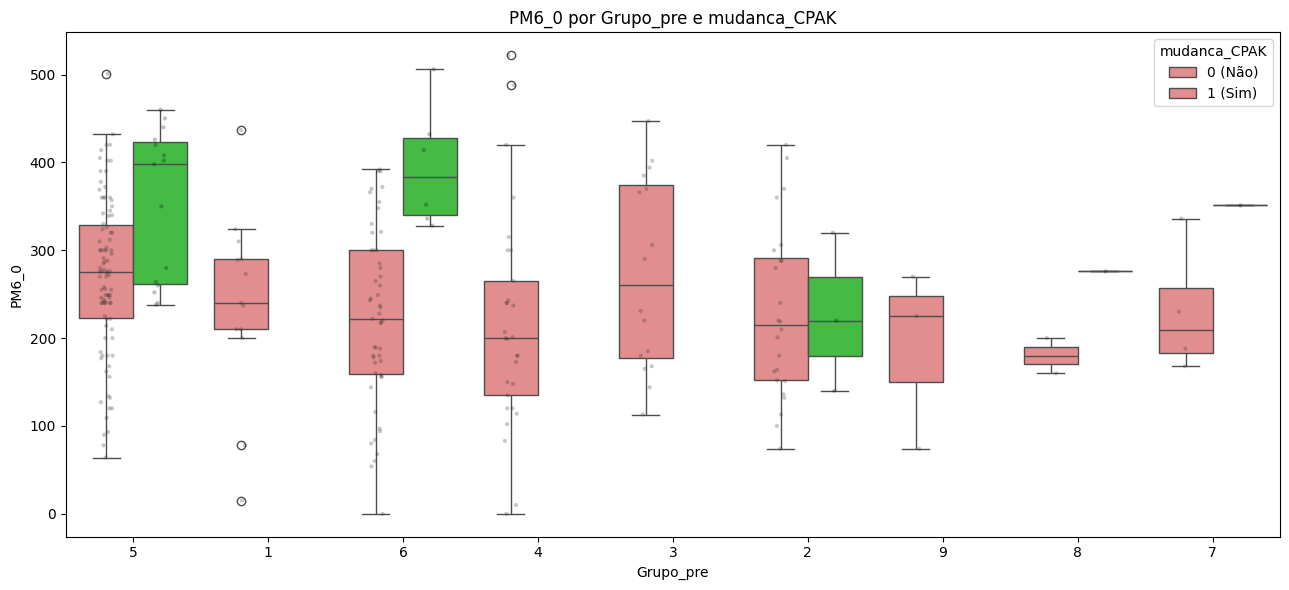

In [44]:
# relação entre Grupo_pre, PM6_0 e mudanca_CPAK(variaveis com correlação mais forte com a target) através de boxplot 
plot_df = ortho_eda_clean[['Grupo_pre', 'PM6_0', 'mudanca_CPAK']].dropna().copy()
plot_df['Grupo_pre'] = plot_df['Grupo_pre'].astype(int).astype(str)
plot_df['mudanca_CPAK'] = plot_df['mudanca_CPAK'].astype(int).astype(str)

plt.figure(figsize=(13, 6))
sns.boxplot(
    data=plot_df,
    x='Grupo_pre',
    y='PM6_0',
    hue='mudanca_CPAK',
    palette={'0': 'lightcoral', '1': 'limegreen'}
)

sns.stripplot(
    data=plot_df,
    x='Grupo_pre',
    y='PM6_0',
    hue='mudanca_CPAK',
    dodge=True,
    alpha=0.25,
    size=3,
    color='black',
    legend=False
)

plt.title('PM6_0 por Grupo_pre e mudanca_CPAK')
plt.xlabel('Grupo_pre')
plt.ylabel('PM6_0')
plt.legend(title='mudanca_CPAK', labels=['0 (Não)', '1 (Sim)'])
plt.tight_layout()
plt.show()
plt.close()

C:\Users\edu23\AppData\Local\Temp\ipykernel_26192\4037697690.py:15: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


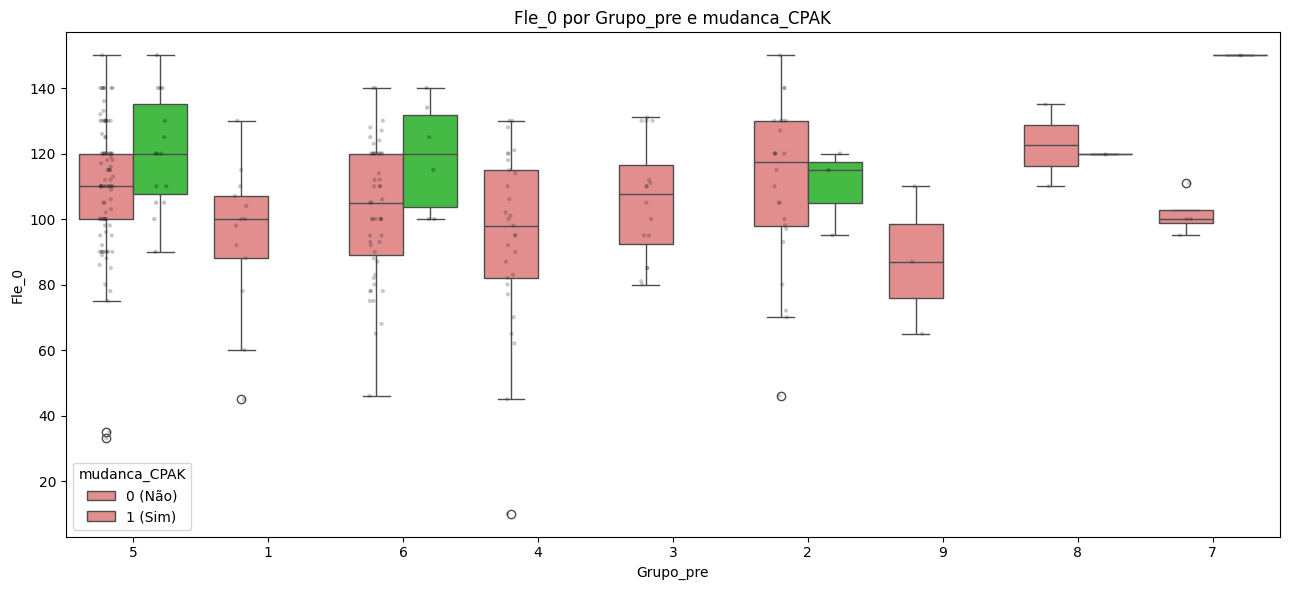

In [45]:
# relação entre Grupo_pre, Fle_0 e mudanca_CPAK
plot_df = ortho_eda_clean[['Grupo_pre', 'Fle_0', 'mudanca_CPAK']].dropna().copy()
plot_df['Grupo_pre'] = plot_df['Grupo_pre'].astype(int).astype(str)
plot_df['mudanca_CPAK'] = plot_df['mudanca_CPAK'].astype(int).astype(str)

plt.figure(figsize=(13, 6))
sns.boxplot(
    data=plot_df,
    x='Grupo_pre',
    y='Fle_0',
    hue='mudanca_CPAK',
    palette={'0': 'lightcoral', '1': 'limegreen'}
)

sns.stripplot(
    data=plot_df,
    x='Grupo_pre',
    y='Fle_0',
    hue='mudanca_CPAK',
    dodge=True,
    alpha=0.25,
    size=3,
    color='black',
    legend=False
)

plt.title('Fle_0 por Grupo_pre e mudanca_CPAK')
plt.xlabel('Grupo_pre')
plt.ylabel('Fle_0')
plt.legend(title='mudanca_CPAK', labels=['0 (Não)', '1 (Sim)'])
plt.tight_layout()
plt.show()
plt.close()

In [46]:
ortho_eda_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262 entries, 0 to 264
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Idade         262 non-null    int64   
 1   Sexo          262 non-null    category
 2   Peso          262 non-null    float64 
 3   Altura_cm     262 non-null    float64 
 4   IMC           262 non-null    float64 
 5   Grupo_pre     262 non-null    category
 6   Fle_0         262 non-null    float64 
 7   EVA_0         262 non-null    float64 
 8   PM6_0         262 non-null    float64 
 9   WD_0          262 non-null    int64   
 10  WR_0          262 non-null    float64 
 11  WAtotal_0     262 non-null    float64 
 12  WT_0          262 non-null    int64   
 13  mudanca_CPAK  262 non-null    category
dtypes: category(3), float64(8), int64(3)
memory usage: 34.0 KB


In [ ]:
# última verificação do estado do dataframe limpo para a modelação
ortho_eda_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 262 entries, 0 to 264
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Idade         262 non-null    int64   
 1   Sexo          262 non-null    category
 2   Peso          262 non-null    float64 
 3   Altura_cm     262 non-null    float64 
 4   IMC           262 non-null    float64 
 5   Grupo_pre     262 non-null    category
 6   Fle_0         262 non-null    float64 
 7   EVA_0         262 non-null    float64 
 8   PM6_0         262 non-null    float64 
 9   WD_0          262 non-null    int64   
 10  WR_0          262 non-null    float64 
 11  WAtotal_0     262 non-null    float64 
 12  WT_0          262 non-null    int64   
 13  mudanca_CPAK  262 non-null    category
dtypes: category(3), float64(8), int64(3)
memory usage: 34.0 KB
